<a href="https://www.kaggle.com/code/sonawanelalitsunil/retail-demand-pricing-analytics-ml?scriptVersionId=229998838" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/inventory-optimization-for-retail/inventory_monitoring.csv
/kaggle/input/inventory-optimization-for-retail/demand_forecasting.csv
/kaggle/input/inventory-optimization-for-retail/pricing_optimization.csv


## Title: 📊 Retail Demand & Pricing Analytics

#### Description:
Optimizing inventory and pricing decisions with data-driven insights. This project analyzes demand trends, pricing strategies, and stock levels to enhance profitability and efficiency in retail operations. 🛒💰

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/inventory-optimization-for-retail/demand_forecasting.csv')

In [3]:
df.head()

,Product ID,Date,Store ID,Sales Quantity,Price,Promotions,Seasonality Factors,External Factors,Demand Trend,Customer Segments
0,4277,2024-01-03,48,330,24.38,No,Festival,Competitor Pricing,Increasing,Regular
1,5540,2024-04-29,10,334,74.98,Yes,Holiday,Weather,Stable,Premium
2,5406,2024-01-11,67,429,24.83,Yes,Holiday,Economic Indicator,Decreasing,Premium
3,5617,2024-04-04,17,298,13.41,No,NaN,Economic Indicator,Stable,Regular
4,3480,2024-12-14,33,344,94.96,Yes,Festival,Weather,Increasing,Regular


In [4]:
df.tail()

,Product ID,Date,Store ID,Sales Quantity,Price,Promotions,Seasonality Factors,External Factors,Demand Trend,Customer Segments
9995,6545,2024-11-26,54,47,47.12,No,NaN,Competitor Pricing,Decreasing,Budget
9996,4341,2024-04-08,82,59,65.11,No,Festival,NaN,Increasing,Budget
9997,8679,2024-02-16,55,481,59.97,No,Holiday,Economic Indicator,Stable,Premium
9998,6281,2024-02-15,97,142,48.70,No,Festival,NaN,Decreasing,Regular
9999,4750,2024-03-19,18,19,42.43,Yes,Festival,NaN,Decreasing,Regular


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product ID           10000 non-null  int64  
 1   Date                 10000 non-null  object 
 2   Store ID             10000 non-null  int64  
 3   Sales Quantity       10000 non-null  int64  
 4   Price                10000 non-null  float64
 5   Promotions           10000 non-null  object 
 6   Seasonality Factors  6685 non-null   object 
 7   External Factors     7574 non-null   object 
 8   Demand Trend         10000 non-null  object 
 9   Customer Segments    10000 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 781.4+ KB


In [6]:
df.describe()

,Product ID,Store ID,Sales Quantity,Price
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,5533.521700,50.264900,248.728900,52.447878
std,2568.312468,28.656333,143.767452,27.459355
min,1000.000000,1.000000,1.000000,5.000000
25%,3319.000000,26.000000,125.000000,28.480000
50%,5579.000000,50.000000,249.000000,52.330000
75%,7696.500000,75.000000,373.000000,76.252500
max,9998.000000,99.000000,499.000000,99.990000


In [7]:
df.isnull().sum()

Product ID                0
Date                      0
Store ID                  0
Sales Quantity            0
Price                     0
Promotions                0
Seasonality Factors    3315
External Factors       2426
Demand Trend              0
Customer Segments         0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(10000, 10)

In [10]:
df.dtypes

Product ID               int64
Date                    object
Store ID                 int64
Sales Quantity           int64
Price                  float64
Promotions              object
Seasonality Factors     object
External Factors        object
Demand Trend            object
Customer Segments       object
dtype: object

In [11]:
df.columns

Index(['Product ID', 'Date', 'Store ID', 'Sales Quantity', 'Price',
       'Promotions', 'Seasonality Factors', 'External Factors', 'Demand Trend',
       'Customer Segments'],
      dtype='object')

## Data visualizations

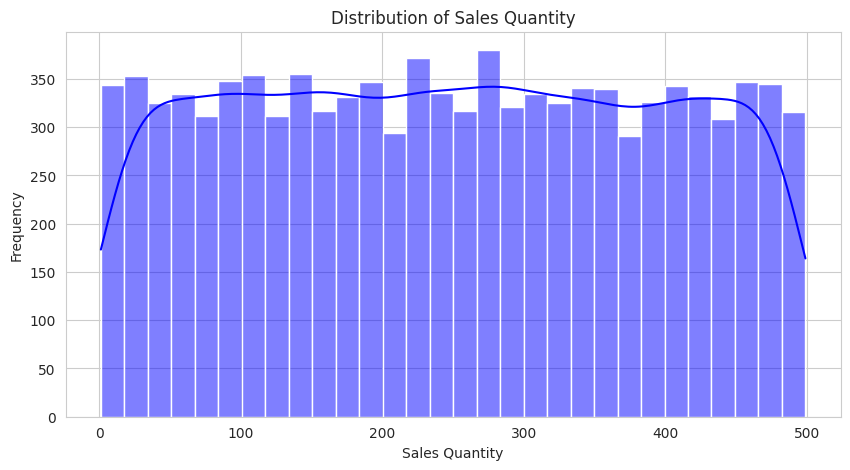

In [12]:
# Set style
sns.set_style("whitegrid")

# 1. Sales Quantity Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Sales Quantity'], bins=30, kde=True, color='blue')
plt.title('Distribution of Sales Quantity')
plt.xlabel('Sales Quantity')
plt.ylabel('Frequency')
plt.show()

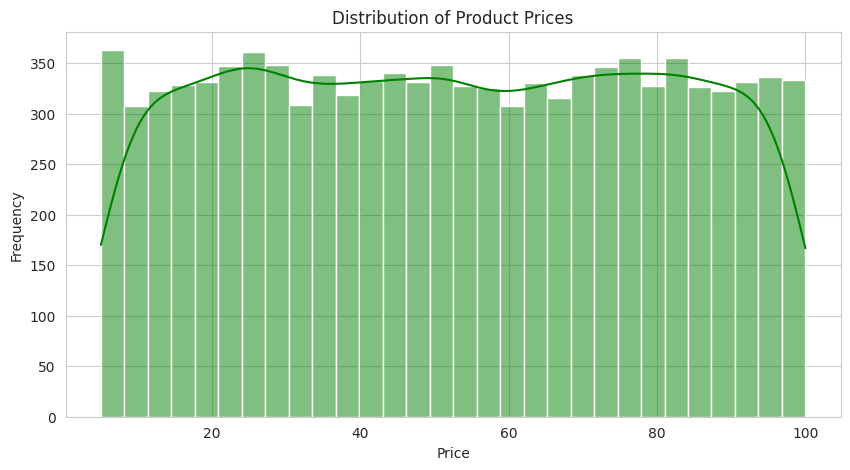

In [13]:
# 2. Price Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], bins=30, kde=True, color='green')
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

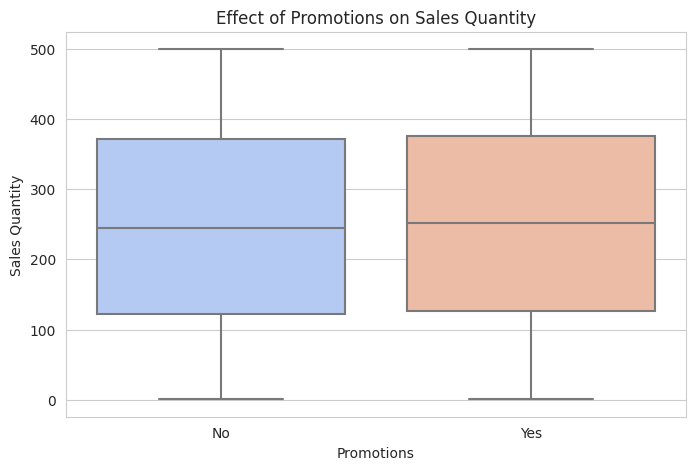

In [14]:
# 3. Promotions Impact on Sales
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Promotions'], y=df['Sales Quantity'], palette='coolwarm')
plt.title('Effect of Promotions on Sales Quantity')
plt.xlabel('Promotions')
plt.ylabel('Sales Quantity')
plt.show()

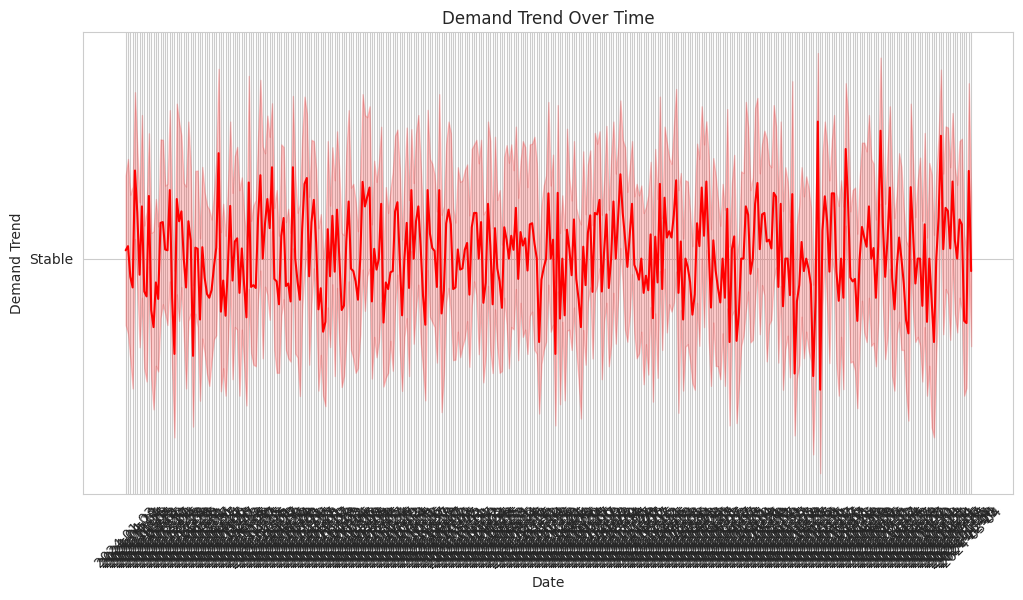

In [15]:
# 4. Demand Trend Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(x=df['Date'], y=df['Demand Trend'], color='red')
plt.title('Demand Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Demand Trend')
plt.xticks(rotation=45)
plt.show()

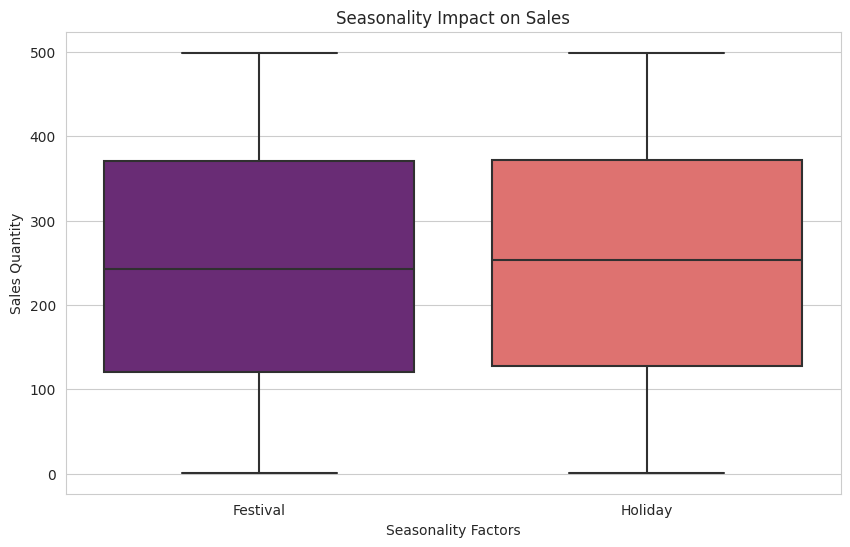

In [16]:
# 5. Seasonality Impact on Sales
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Seasonality Factors'], y=df['Sales Quantity'], palette='magma')
plt.title('Seasonality Impact on Sales')
plt.xlabel('Seasonality Factors')
plt.ylabel('Sales Quantity')
plt.show()

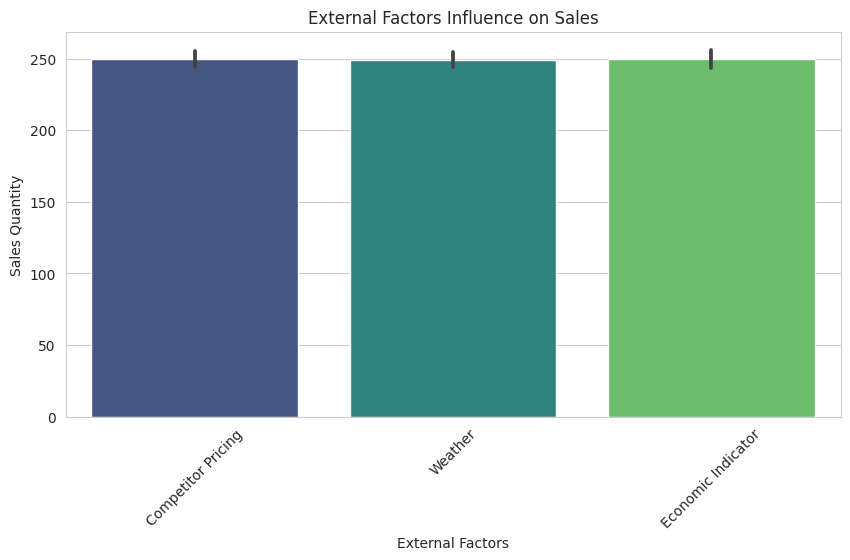

In [17]:
# 6. External Factors Impact on Sales
plt.figure(figsize=(10, 5))
sns.barplot(x=df['External Factors'], y=df['Sales Quantity'], palette='viridis')
plt.title('External Factors Influence on Sales')
plt.xlabel('External Factors')
plt.ylabel('Sales Quantity')
plt.xticks(rotation=45)
plt.show()

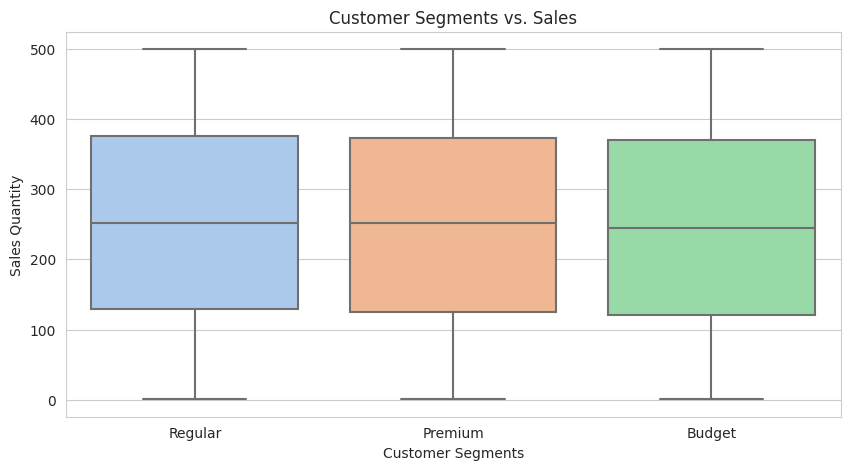

In [18]:
# 7. Customer Segments and Sales
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Customer Segments'], y=df['Sales Quantity'], palette='pastel')
plt.title('Customer Segments vs. Sales')
plt.xlabel('Customer Segments')
plt.ylabel('Sales Quantity')
plt.show()

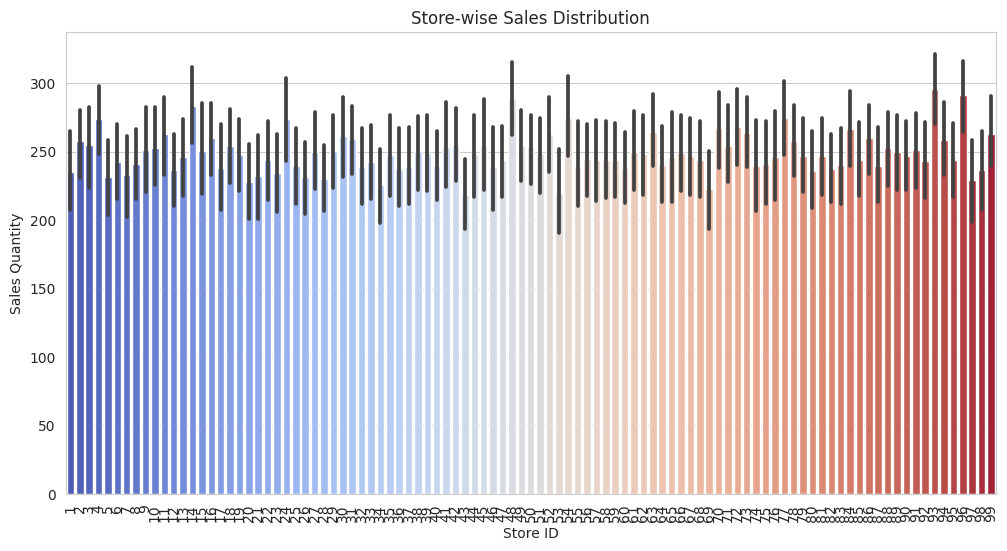

In [19]:
# 8. Store-wise Sales Analysis
plt.figure(figsize=(12, 6))
sns.barplot(x=df['Store ID'], y=df['Sales Quantity'], palette='coolwarm')
plt.title('Store-wise Sales Distribution')
plt.xlabel('Store ID')
plt.ylabel('Sales Quantity')
plt.xticks(rotation=90)
plt.show()

## Predictive Modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
# Drop non-numeric columns that are not needed for ML
categorical_cols = ['Product ID', 'Date', 'Store ID']
df.drop(columns=categorical_cols, inplace=True, errors='ignore')

In [22]:
# Label Encoding for categorical features
le = LabelEncoder()
categorical_features = df.select_dtypes(include=['object']).columns
for col in categorical_features:
    df[col] = le.fit_transform(df[col].astype(str))


In [23]:
# Handling missing values (if any)
df.fillna(df.median(), inplace=True)

In [24]:
# Splitting data into features and target
X = df.drop(columns=['Sales Quantity'])  # Assuming 'Sales Quantity' is the target variable
y = df['Sales Quantity']

In [25]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# Scaling the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor()
}

In [28]:
# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}


In [29]:
# Display model performance
print("Model Performance:")
for model, metrics in results.items():
    print(f"{model}: MAE={metrics['MAE']:.2f}, RMSE={metrics['RMSE']:.2f}, R2={metrics['R2']:.2%}")

Model Performance:
Linear Regression: MAE=125.64, RMSE=145.23, R2=-0.21%
Random Forest: MAE=130.81, RMSE=154.45, R2=-13.33%
Gradient Boosting: MAE=126.05, RMSE=145.98, R2=-1.25%
SVR: MAE=125.57, RMSE=145.10, R2=-0.02%
KNN: MAE=132.28, RMSE=156.76, R2=-16.75%
Decision Tree: MAE=171.30, RMSE=207.87, R2=-105.28%


<Figure size 1000x500 with 0 Axes>

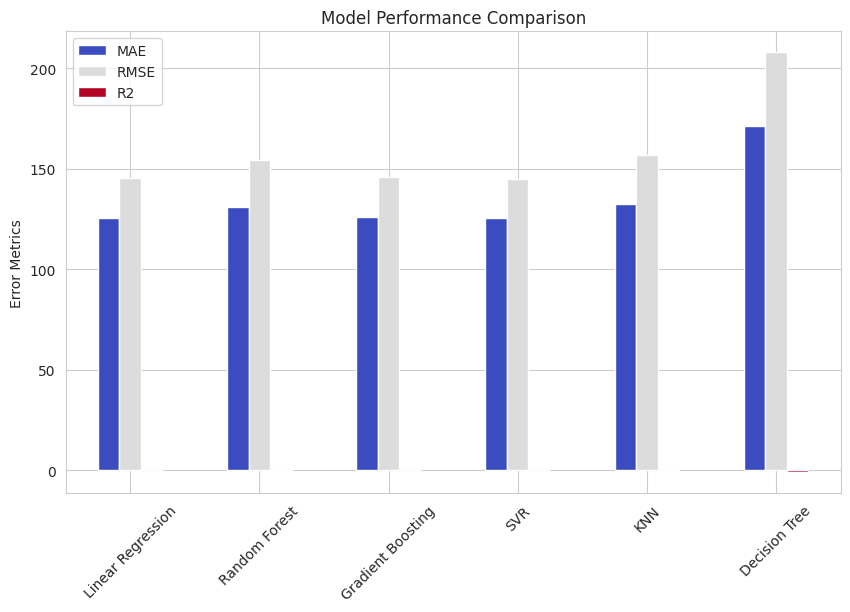

In [30]:
# Plot model comparison
plt.figure(figsize=(10, 5))
metrics_df = pd.DataFrame(results).T
metrics_df[['MAE', 'RMSE', 'R2']].plot(kind='bar', figsize=(10, 6), colormap='coolwarm')
plt.xticks(rotation=45)
plt.title('Model Performance Comparison')
plt.ylabel('Error Metrics')
plt.show()

## Thankyou..pls upvote!!!!